<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/BeefMicrobialPopulationPrediction-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electronic Nose Project
## Beef Microbial Population Prediction
(c)2024 Djoko Purwanto, Dept. of Electrical Engineering <br>
Institut Teknologi Sepuluh Nopember (ITS) <br>
djoko@its.ac.id

Nama Mahasiswa: DODY SUHENDRA
NRP : 6022251073
Mata Kuliah : Kecerdasan Buatan

In [ ]:
import platform
import psutil
import tensorflow as tf
from datetime import datetime

def get_system_info():
    info = {}
    # Get system information
    info['platform'] = platform.system()
    info['platform-version'] = platform.version()
    info['architecture'] = platform.machine()
    info['hostname'] = platform.node()
    info['processor'] = platform.processor()
    info['ram'] = str(round(psutil.virtual_memory().total / (1024.0 **3))) + ' GB'
    return info

print(f'Program start ...')
# Print the system information
system_info = get_system_info()
for key, value in system_info.items():
    print(f'{key}: {value}')

# Print TensorFlow version
print(f'TensorFlow version: {tf.__version__}')
if tf.config.list_physical_devices('GPU'):
    print(f'GPU is being used by TensorFlow')
else: print(f'GPU is unavailable for TensorFlow')

# Get the current time
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
# Print the current time
print(f'The current time is: {current_time}')

Program start ...
platform: Linux
platform-version: #1 SMP Mon Feb  2 12:27:57 UTC 2026
architecture: x86_64
hostname: 07251c383370
processor: x86_64
ram: 13 GB
TensorFlow version: 2.20.0
GPU is unavailable for TensorFlow
The current time is: 2026-05-07 12:09:00


### (1) Read and Visualize Data

In [ ]:
import pandas as pd

df_sheets = pd.read_excel('e-nose_dataset_12_beef_cuts.xlsx',
    sheet_name=['7.Rib_eye'])
df_sheets['7.Rib_eye']

,Minute,TVC,Label,MQ135,MQ136,MQ137,MQ138,MQ2,MQ3,MQ4,MQ5,MQ6,MQ8,MQ9
0,1,1.875890,1,17.55,26.30,5.07,18.44,15.66,16.31,20.19,4.41,2.88,24.71,14.23
1,2,1.875890,1,17.55,27.50,5.05,18.94,14.91,16.58,20.09,4.33,2.85,24.71,14.34
2,3,1.875890,1,17.33,26.56,5.07,18.69,14.03,16.24,19.62,4.41,2.88,24.71,14.11
3,4,1.875890,1,17.26,26.96,5.07,18.86,14.73,16.24,19.72,4.35,2.90,24.36,14.06
4,5,1.875890,1,17.33,26.82,4.98,18.86,15.03,16.38,19.90,4.35,2.91,24.83,14.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2215,2216,5.758033,4,8.69,2.78,21.02,13.32,3.87,7.88,2.24,32.42,33.80,16.33,10.87
2216,2217,5.758033,4,8.69,2.84,21.02,13.32,4.16,7.94,2.24,32.24,33.80,16.46,10.99
2217,2218,5.758033,4,8.76,2.82,21.11,13.27,4.73,8.01,2.25,32.61,33.58,16.60,10.95
2218,2219,5.758033,4,8.73,2.82,21.31,13.27,4.40,8.01,2.25,32.42,33.58,16.81,10.99


In [ ]:
print(df_sheets['7.Rib_eye'].head(),'\n')
print(df_sheets['7.Rib_eye'].head())

   Minute      TVC  Label  MQ135  MQ136  MQ137  MQ138    MQ2    MQ3    MQ4  \
0       1  1.87589      1  17.55  26.30   5.07  18.44  15.66  16.31  20.19   
1       2  1.87589      1  17.55  27.50   5.05  18.94  14.91  16.58  20.09   
2       3  1.87589      1  17.33  26.56   5.07  18.69  14.03  16.24  19.62   
3       4  1.87589      1  17.26  26.96   5.07  18.86  14.73  16.24  19.72   
4       5  1.87589      1  17.33  26.82   4.98  18.86  15.03  16.38  19.90   

    MQ5   MQ6    MQ8    MQ9  
0  4.41  2.88  24.71  14.23  
1  4.33  2.85  24.71  14.34  
2  4.41  2.88  24.71  14.11  
3  4.35  2.90  24.36  14.06  
4  4.35  2.91  24.83  14.17   

   Minute      TVC  Label  MQ135  MQ136  MQ137  MQ138    MQ2    MQ3    MQ4  \
0       1  1.87589      1  17.55  26.30   5.07  18.44  15.66  16.31  20.19   
1       2  1.87589      1  17.55  27.50   5.05  18.94  14.91  16.58  20.09   
2       3  1.87589      1  17.33  26.56   5.07  18.69  14.03  16.24  19.62   
3       4  1.87589      1  17.26  26.

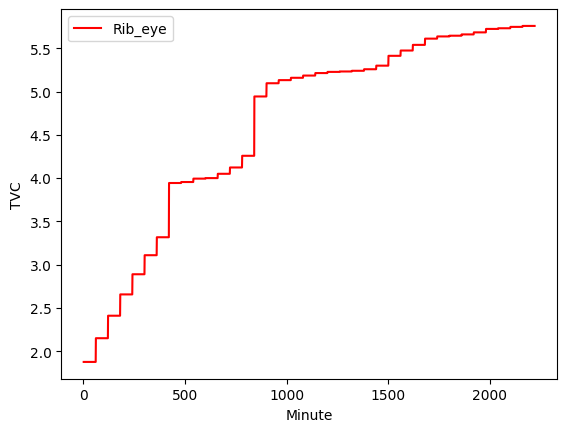

In [ ]:
import matplotlib.pyplot as plt

minute_1 = df_sheets['7.Rib_eye']['Minute'].values
tvc_1 = df_sheets['7.Rib_eye']['TVC'].values

plt.figure()
plt.plot(minute_1,tvc_1,'r-')
plt.legend(['Rib_eye']); plt.xlabel('Minute'); plt.ylabel('TVC');

### (2) Create Dataset

In [ ]:
df_dataset = pd.DataFrame()
df_dataset = df_sheets['7.Rib_eye'].copy()
df_dataset.drop(columns=['Minute', 'Label'], inplace=True)
df_dataset.head()

,TVC,MQ135,MQ136,MQ137,MQ138,MQ2,MQ3,MQ4,MQ5,MQ6,MQ8,MQ9
0,1.87589,17.55,26.30,5.07,18.44,15.66,16.31,20.19,4.41,2.88,24.71,14.23
1,1.87589,17.55,27.50,5.05,18.94,14.91,16.58,20.09,4.33,2.85,24.71,14.34
2,1.87589,17.33,26.56,5.07,18.69,14.03,16.24,19.62,4.41,2.88,24.71,14.11
3,1.87589,17.26,26.96,5.07,18.86,14.73,16.24,19.72,4.35,2.90,24.36,14.06
4,1.87589,17.33,26.82,4.98,18.86,15.03,16.38,19.90,4.35,2.91,24.83,14.17


In [ ]:
ds_values = df_dataset.values

ds_inputs = ds_values[:,1:]
ds_outputs = ds_values[:,0:1]

print(f'input shape  : {ds_inputs.shape}')
print(f'output shape : {ds_outputs.shape}')
print(ds_inputs[0:5,:])
print(ds_outputs[0:5,:])

input shape  : (2220, 11)
output shape : (2220, 1)
[[17.55 26.3   5.07 18.44 15.66 16.31 20.19  4.41  2.88 24.71 14.23]
 [17.55 27.5   5.05 18.94 14.91 16.58 20.09  4.33  2.85 24.71 14.34]
 [17.33 26.56  5.07 18.69 14.03 16.24 19.62  4.41  2.88 24.71 14.11]
 [17.26 26.96  5.07 18.86 14.73 16.24 19.72  4.35  2.9  24.36 14.06]
 [17.33 26.82  4.98 18.86 15.03 16.38 19.9   4.35  2.91 24.83 14.17]]
[[1.87589]
 [1.87589]
 [1.87589]
 [1.87589]
 [1.87589]]


#### Input normalization

In [ ]:
import numpy as np

inp_min = np.min(ds_inputs); inp_max = np.max(ds_inputs)
print(f'inputs values --> min = {inp_min}; max = {inp_max}')

inputs values --> min = 3.72; max = 46.51


Set new input min and input max, then do input normalization

In [ ]:
def normalization(x,xmin,xmax):
    return 2*(x-xmin)/(xmax-xmin) - 1

inp_min, inp_max = 0.0, 50.0
ds_inputs_norm = normalization(ds_inputs, inp_min, inp_max)

print(f'input normalization shape: {ds_inputs_norm.shape}')
print(ds_inputs_norm[0:5,:])

input normalization shape: (2220, 11)
[[-0.286  -0.3768 -0.682  -0.1508 -0.3392 -0.0372 -0.5084 -0.6392 -0.4296
   0.6116 -0.424 ]
 [-0.28   -0.3664 -0.6756 -0.1428 -0.328  -0.0328 -0.4964 -0.6348 -0.4248
   0.632  -0.4192]
 [-0.292  -0.3896 -0.6796 -0.1584 -0.366  -0.0416 -0.5104 -0.6264 -0.4296
   0.5916 -0.4332]
 [-0.2888 -0.3796 -0.6796 -0.1508 -0.3472 -0.0552 -0.5044 -0.642  -0.4296
   0.6216 -0.4356]
 [-0.292  -0.3872 -0.6808 -0.1544 -0.358  -0.0508 -0.5044 -0.6392 -0.432
   0.6016 -0.4376]]


#### Split dataset into 70% train and 30% test set

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(ds_inputs_norm, ds_outputs, test_size=0.3, random_state=42)

print(f'Train set shape: {X_train.shape}')
print(f'Test set shape : {X_test.shape}')

Train set shape: (1554, 11)
Test set shape : (666, 11)


### (3) Build Model

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(8, activation='sigmoid',input_dim=X_train.shape[1]),
    tf.keras.layers.Dense(1)])

model.summary()
print('Model created')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

Model created


### (4) Train model

In [ ]:
import time
import datetime

epochs = 5000
batch_size = int(0.1*len(X_train))
print('Batch size: ',batch_size)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_mse', factor=0.1, patience=50, min_lr=1e-6)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='mse', patience=75, restore_best_weights=True)

optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-2)
model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mse'])

starttime = time.time()

model_history = model.fit(X_train,Y_train, epochs=epochs,
    validation_data=(X_test, Y_test), verbose=2, batch_size=batch_size,
    callbacks=[reduce_lr, early_stopping] )

stoptime =  time.time()-starttime
trainingtime = datetime.timedelta(seconds=stoptime)
print(f'\nTraining time : {trainingtime}')
print('End of training')

Batch size:  177
Epoch 1/5000
11/11 - 1s - 107ms/step - loss: 15.8674 - mse: 15.8674 - val_loss: 8.1438 - val_mse: 8.1438 - learning_rate: 0.0100
Epoch 2/5000
11/11 - 0s - 10ms/step - loss: 5.1531 - mse: 5.1531 - val_loss: 2.2754 - val_mse: 2.2754 - learning_rate: 0.0100
Epoch 3/5000
11/11 - 0s - 9ms/step - loss: 1.5740 - mse: 1.5740 - val_loss: 1.2455 - val_mse: 1.2455 - learning_rate: 0.0100
Epoch 4/5000
11/11 - 0s - 9ms/step - loss: 1.2272 - mse: 1.2272 - val_loss: 1.3598 - val_mse: 1.3598 - learning_rate: 0.0100
Epoch 5/5000
11/11 - 0s - 10ms/step - loss: 1.2813 - mse: 1.2813 - val_loss: 1.2955 - val_mse: 1.2955 - learning_rate: 0.0100
Epoch 6/5000
11/11 - 0s - 9ms/step - loss: 1.1923 - mse: 1.1923 - val_loss: 1.2022 - val_mse: 1.2022 - learning_rate: 0.0100
Epoch 7/5000
11/11 - 0s - 10ms/step - loss: 1.1267 - mse: 1.1267 - val_loss: 1.1722 - val_mse: 1.1722 - learning_rate: 0.0100
Epoch 8/5000
11/11 - 0s - 10ms/step - loss: 1.1132 - mse: 1.1132 - val_loss: 1.1523 - val_mse: 1.1523

### (5) Performance Evaluation
#### Training

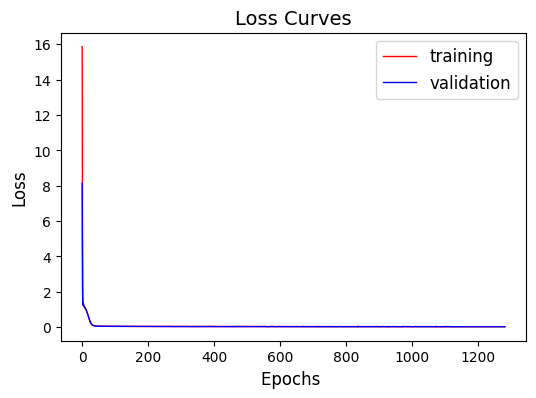

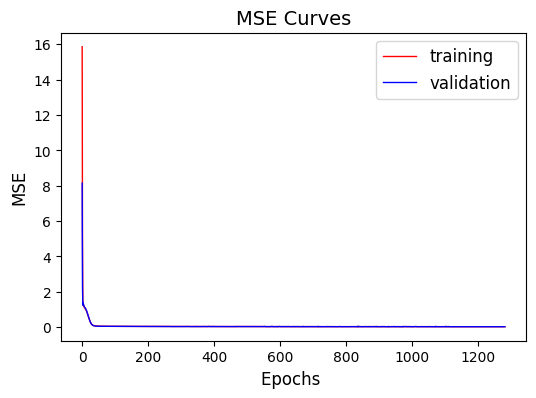

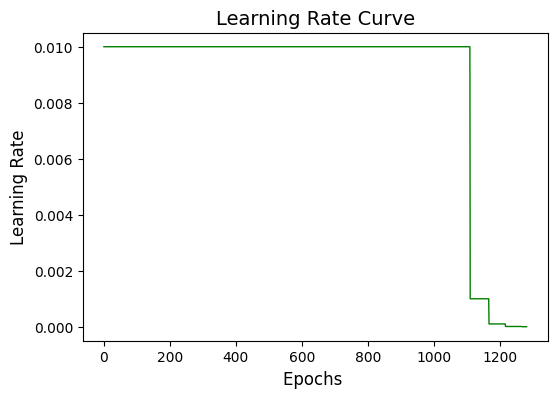

In [ ]:
plt.figure(figsize=[6, 4])
plt.plot(model_history.history['loss'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_loss'], 'b', linewidth=1.0)
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs ', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss Curves', fontsize=14)
plt.show()

plt.figure(figsize=[6, 4])
plt.plot(model_history.history['mse'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_mse'], 'b', linewidth=1.0)
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs ', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('MSE Curves', fontsize=14)
plt.show()

plt.figure(figsize=[6, 4])
plt.plot(model_history.history['learning_rate'], 'g', linewidth=1.0)
plt.xlabel('Epochs ', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Curve', fontsize=14)
plt.show()

#### Model output

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


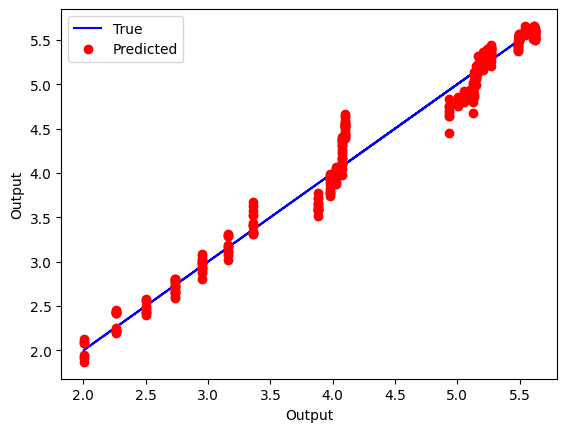

In [ ]:
Pred_test = model.predict(X_test)
plt.figure()
plt.plot(Y_test,Y_test,'b-',Y_test,Pred_test,'ro')
plt.legend(['True','Predicted']); plt.xlabel('Output'); plt.ylabel('Output');

### (6) Explore the Model
Model weights and biases

In [ ]:
dense_layer1 = model.layers[0]
weights1, biases1 = dense_layer1.get_weights()
print(f'Weights_1 shape: {weights1.shape}')
print(f'Biases_1 shape: {biases1.shape}')
print(f'Weights_1:\n {weights1}')
print(f'Biases_1 :\n {biases1}')

dense_layer2 = model.layers[1]
weights2, biases2 = dense_layer2.get_weights()
print(f'Weights_2 shape: {weights2.shape}')
print(f'Biases_2 shape: {biases2.shape}')
print(f'Weights_2:\n {weights2}')
print(f'Biases_2 :\n {biases2}')

Weights_1 shape: (11, 20)
Biases_1 shape: (20,)
Weights_1:
 [[-1.16176045e+00  1.25712919e+00 -1.22233832e+00 -8.36228669e-01
  -2.09379244e+00 -2.57105374e+00  1.24376488e+00 -7.62155592e-01
   1.07244527e+00 -1.51896095e+00  5.00998259e-01 -9.96692181e-01
  -8.12665880e-01  1.07978284e+00 -1.52747083e+00  7.52013028e-02
  -1.67627370e+00 -2.24590135e+00  9.99048114e-01  7.66234338e-01]
 [-7.76636481e-01  1.12429067e-01 -7.63681293e-01 -1.97336420e-01
  -1.31668723e+00 -1.21019137e+00  2.83523142e-01 -4.12518866e-02
   3.40626597e-01 -9.02055502e-01  4.77767617e-01 -3.58903199e-01
   3.01039442e-02 -1.76575050e-01 -8.20407048e-02  8.09654891e-01
  -1.36429799e+00 -9.91750956e-01  7.05223903e-02  2.21582964e-01]
 [ 2.13982773e+00 -2.41697645e+00  1.31363976e+00  8.65683734e-01
   3.10801458e+00  1.30681705e+00  2.30803713e-01  8.92610431e-01
   1.05126953e+00  1.55524760e-01  1.03024387e+00  8.57084155e-01
   1.50310254e+00 -3.93342942e-01  8.65003705e-01  1.20280147e+00
   5.20738602e

Save the model

In [ ]:
model_filename = 'BMPPmodelTF'+tf.__version__+'.keras'

model.save(model_filename)
print(f'Model saved as {model_filename}')

print(f'End of program... ')

Model saved as BMPPmodelTF2.20.0.keras
End of program... 


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
